In [ ]:
# 1. Install dependencies

!pip install kaggle ultralytics pandas opencv-python-headless scikit-learn kagglehub

import os
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
import kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics pandas opencv-python-headless scikit-learn kagglehub --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 41.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0

In [ ]:
import os
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#2. Download Dataset

import kagglehub

# Bee vs Wasp dataset
path_bee_wasp = kagglehub.dataset_download("jerzydziewierz/bee-vs-wasp")
print("Bee/Wasp path:", path_bee_wasp)

# Random Images dataset
path_random = kagglehub.dataset_download("muhammadabubakar691/random-images-dataset")
print("Random dataset path:", path_random)

100%|██████████| 559M/559M [00:34<00:00, 17.0MB/s]

Extracting files...


Bee/Wasp path: /root/.cache/kagglehub/datasets/jerzydziewierz/bee-vs-wasp/versions/1


100%|██████████| 1.03G/1.03G [01:03<00:00, 17.4MB/s]

Extracting files...


Random dataset path: /root/.cache/kagglehub/datasets/muhammadabubakar691/random-images-dataset/versions/1


In [ ]:
#3. Load Bee/Wasp Dataset

csv_path = os.path.join(path_bee_wasp, "kaggle_bee_vs_wasp", "labels.csv")

df_old = pd.read_csv(csv_path)
df_old.columns = df_old.columns.str.strip().str.lower()
df_old['path'] = df_old['path'].apply(lambda x: x.replace('\\', '/'))

df_old = df_old[df_old['label'].isin(['bee', 'wasp'])]

print("Bee/Wasp counts:\n", df_old['label'].value_counts())

Bee/Wasp counts:
 label
wasp    4943
bee     3183
Name: count, dtype: int64


In [ ]:
#4. Load Random Images

base_new_path = os.path.join(path_random, "Final Random Image Dataset")

new_images = []

for root, dirs, files in os.walk(base_new_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, base_new_path)

            new_images.append({
                "path": rel_path,
                "label": "other"
            })

df_new = pd.DataFrame(new_images)

print("Other dataset size:", len(df_new))
print(df_new.head())

Other dataset size: 7767
                        path  label
0  Pets/Birds/train_2097.jpg  other
1  Pets/Birds/train_2298.jpg  other
2  Pets/Birds/train_2668.jpg  other
3  Pets/Birds/train_1976.jpg  other
4  Pets/Birds/train_2368.jpg  other


In [ ]:
#5. Combine + Balance Dataset

df_all = pd.concat([df_old, df_new], ignore_index=True)

print("Before balancing:\n", df_all['label'].value_counts())

# Balance "other"
max_count = df_all['label'].value_counts()[['bee','wasp']].max()

df_other = df_all[df_all['label'] == 'other'].sample(n=max_count, random_state=42)
df_bee_wasp = df_all[df_all['label'].isin(['bee','wasp'])]

df_balanced = pd.concat([df_bee_wasp, df_other], ignore_index=True)

print("After balancing:\n", df_balanced['label'].value_counts())

Before balancing:
 label
other    7767
wasp     4943
bee      3183
Name: count, dtype: int64
After balancing:
 label
wasp     4943
other    4943
bee      3183
Name: count, dtype: int64


In [ ]:
#6. Train / Validation Split

train_df, val_df = train_test_split(
    df_balanced,
    test_size=0.2,
    stratify=df_balanced['label'],
    random_state=42
)

print("Train:", len(train_df), "Validation:", len(val_df))

Train: 10455 Validation: 2614


In [ ]:
#7.Create YOLO Folder Structure

base_path = "/content/bee_wasp_other_dataset"

folders = [
    "train/images", "train/labels",
    "valid/images", "valid/labels"
]

for f in folders:
    os.makedirs(os.path.join(base_path, f), exist_ok=True)

In [ ]:
#8. Path Helper

def get_full_path(img_rel_path):
    return os.path.join(base_new_path, img_rel_path)

In [ ]:
#9. Convert to YOLO Format

class_map = {"bee": 0, "wasp": 1, "other": 2}

def process_data(dataframe, split):
    saved, skipped = 0, 0

    for _, row in dataframe.iterrows():
        img_rel_path = row['path']
        label = row['label']

        # Bee/Wasp path
        if label in ["bee", "wasp"]:
            img_full_path = os.path.join(
                path_bee_wasp,
                "kaggle_bee_vs_wasp",
                img_rel_path
            )
        else:
            img_full_path = get_full_path(img_rel_path)

        if not os.path.exists(img_full_path):
            skipped += 1
            continue

        img = cv2.imread(img_full_path)
        if img is None:
            skipped += 1
            continue

        h, w, _ = img.shape

        # Full-image bounding box
        x_center, y_center = 0.5, 0.5
        width, height = 1.0, 1.0

        cls_id = class_map[label]

        img_name = os.path.basename(img_rel_path)

        out_img = os.path.join(base_path, split, "images", img_name)
        out_lbl = os.path.join(base_path, split, "labels", img_name.rsplit('.',1)[0] + ".txt")

        cv2.imwrite(out_img, img)

        with open(out_lbl, "w") as f:
            f.write(f"{cls_id} {x_center} {y_center} {width} {height}\n")

        saved += 1

    print(f"{split}: Saved {saved} | Skipped {skipped}")

In [ ]:
#10. Run Data Processing

process_data(train_df, "train")
process_data(val_df, "valid")

In [ ]:
#11. Create data.yaml

data_yaml = f"""
path: {base_path}
train: train/images
val: valid/images

names:
  0: bee
  1: wasp
  2: other
"""

with open(os.path.join(base_path, "data.yaml"), "w") as f:
    f.write(data_yaml)

print("data.yaml created")

In [ ]:
#12. Train YOLOv8

model = YOLO("yolov8s.pt")

model.train(
    data=os.path.join(base_path, "data.yaml"),
    epochs=5,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bee_wasp_other_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b8e6b6eb770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
metrics = model.val()


print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1566.8±691.4 MB/s, size: 76.5 KB)
val: Scanning /content/bee_wasp_other_dataset/valid/labels.cache... 2613 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2613/2613 996.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 164/164 4.7it/s 35.0s
                   all       2613       2613      0.934      0.937      0.979      0.976
                   bee        636        636      0.889      0.983      0.969      0.969
                  wasp        989        989      0.968       0.86       0.98      0.978
                 other        988        988      0.946      0.968      0.988       0.98
Speed: 0.9ms preprocess, 8.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/d

In [ ]:
#13. Test Predictions

sample = val_df.sample(5, random_state=42)

for _, row in sample.iterrows():
    img_rel_path = row['path']
    label = row['label']

    if label in ["bee", "wasp"]:
        img_path = os.path.join(path_bee_wasp, "kaggle_bee_vs_wasp", img_rel_path)
    else:
        img_path = get_full_path(img_rel_path)

    results = model.predict(source=img_path, conf=0.3, save=True)

    latest = max(glob.glob('/content/runs/detect/predict*'), key=os.path.getmtime)
    img_out = os.listdir(latest)[0]
    img_out_path = os.path.join(latest, img_out)

    img = cv2.imread(img_out_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Prediction")
    plt.show()

Saving Bee_Image_1.jpg to Bee_Image_1.jpg

image 1/1 /content/Bee_Image_1.jpg: 544x640 1 bee, 1 other, 56.4ms
Speed: 4.0ms preprocess, 56.4ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict2


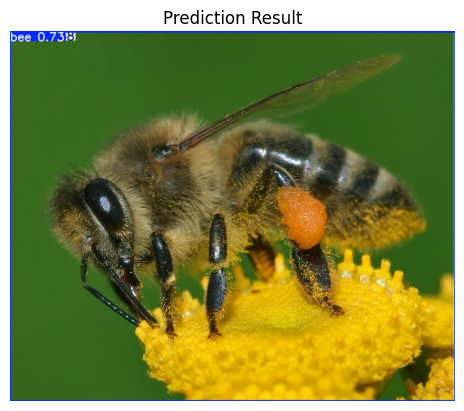

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#14. Test on Unseen Images

from google.colab import files
import os, glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load model
# Update the path to load the trained model from the correct location
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Upload image
uploaded = files.upload()

for img_name in uploaded.keys():

    img_path = os.path.join("/content", img_name)

    # Run prediction
    results = model.predict(
        source=img_path,
        conf=0.3,
        save=True
    )

    # Get latest prediction folder
    latest_folder = max(glob.glob('/content/runs/detect/predict*'), key=os.path.getmtime)

    # Get output image path safely
    output_files = os.listdir(latest_folder)
    output_image_path = os.path.join(latest_folder, output_files[0])

    # DISPLAY
    img = cv2.imread(output_image_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Prediction Result")
    plt.axis("off")
    plt.show()

    # DOWNLOAD
    files.download(output_image_path)

In [ ]:
#15. Test on Unseen Videos of Bee

In [22]:
from google.colab import files
import os, glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load model
model = YOLO("/content/runs/detect/train/weights/best.pt")

uploaded = files.upload()

for file_name in uploaded.keys():
    file_path = os.path.join("/content", file_name)

    # Skip empty files
    if os.path.getsize(file_path) == 0:
        print(f" Skipping {file_name} (empty file)")
        continue

    # Run prediction
    results = model.predict(
        source=file_path,
        conf=0.3,
        save=True
    )

    latest_folder = max(glob.glob('/content/runs/detect/predict*'), key=os.path.getmtime)
    output_files = os.listdir(latest_folder)

    video_files = [f for f in output_files if f.endswith(('.mp4', '.avi', '.mov'))]
    image_files = [f for f in output_files if f.endswith(('.jpg', '.jpeg', '.png'))]

    if video_files:
        output_path = os.path.join(latest_folder, video_files[0])
        print(" Processed video:", output_path)
        files.download(output_path)

    elif image_files:
        output_path = os.path.join(latest_folder, image_files[0])
        print(" Processed image:", output_path)

        img = cv2.imread(output_path)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Prediction Result")
        plt.axis("off")
        plt.show()

        files.download(output_path)

    else:
        print(" No output file found!")

Saving Bee_Video_1.mp4 to Bee_Video_1 (1).mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/725) /content/Bee_Video_1 (1).mp4: 384x640 1 bee, 14.6ms
video 1/1 (frame 2/725) /content/Bee_Video_1 (1).mp4: 384x640 1 bee, 11.6ms
video 1/1 (frame 3/725) /content/Bee_Video_1 (1).mp4: 384x640 1 bee, 11.8ms
video 1/1 (frame 4/725) /content/Bee_Video_1 (1).mp4: 384x640 1 bee, 13.8ms
video 1/1 (frame 5/725) /content/Bee_Video_1 (1).mp4: 384x640 1 bee, 10.6ms
video 1/1 (frame 6/725) /content

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#15. Test on Unseen Videos of Wasp

In [23]:
from google.colab import files
import os, glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load model
model = YOLO("/content/runs/detect/train/weights/best.pt")

uploaded = files.upload()

for file_name in uploaded.keys():
    file_path = os.path.join("/content", file_name)

    # Skip empty files
    if os.path.getsize(file_path) == 0:
        print(f" Skipping {file_name} (empty file)")
        continue

    # Run prediction
    results = model.predict(
        source=file_path,
        conf=0.3,
        save=True
    )

    latest_folder = max(glob.glob('/content/runs/detect/predict*'), key=os.path.getmtime)
    output_files = os.listdir(latest_folder)

    video_files = [f for f in output_files if f.endswith(('.mp4', '.avi', '.mov'))]
    image_files = [f for f in output_files if f.endswith(('.jpg', '.jpeg', '.png'))]

    if video_files:
        output_path = os.path.join(latest_folder, video_files[0])
        print(" Processed video:", output_path)
        files.download(output_path)

    elif image_files:
        output_path = os.path.join(latest_folder, image_files[0])
        print(" Processed image:", output_path)

        img = cv2.imread(output_path)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Prediction Result")
        plt.axis("off")
        plt.show()

        files.download(output_path)

    else:
        print(" No output file found!")

Saving Wasp_Video_1.mp4 to Wasp_Video_1 (1).mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/143) /content/Wasp_Video_1 (1).mp4: 384x640 1 wasp, 11.3ms
video 1/1 (frame 2/143) /content/Wasp_Video_1 (1).mp4: 384x640 1 wasp, 10.6ms
video 1/1 (frame 3/143) /content/Wasp_Video_1 (1).mp4: 384x640 1 wasp, 10.6ms
video 1/1 (frame 4/143) /content/Wasp_Video_1 (1).mp4: 384x640 1 wasp, 10.6ms
video 1/1 (frame 5/143) /content/Wasp_Video_1 (1).mp4: 384x640 1 wasp, 10.6ms
video 1/1 (frame 6/1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import drive
import glob, os, shutil

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Find latest training folder
train_folders = glob.glob('/content/runs/detect/train*')
latest_train = max(train_folders, key=os.path.getmtime)

# 3. Path to best model
best_model_path = os.path.join(latest_train, "weights", "best.pt")

# 4. Copy to Drive
save_path = "/content/drive/MyDrive/yolov8_bee_wasp.pt"
shutil.copy(best_model_path, save_path)

print("Model saved at:", save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved at: /content/drive/MyDrive/yolov8_bee_wasp.pt
